# Experiment 4: Comparative Study of Deep Convolutional Neural Network Architectures Using Transfer Learning

**CS3807 - Deep Learning Laboratory**

Model used for Transfer Learning: **MobileNetV2**
Dataset: **CIFAR-10**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input, Resizing
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import seaborn as sns

## Task 1: Dataset Preparation

In [ ]:
!pip install -q datasets
from datasets import load_dataset

dataset = load_dataset("uoft-cs/cifar10")

train_ds = dataset['train']
test_ds = dataset['test']

x_train = np.stack([np.array(img) for img in train_ds['img']]).astype('float32') / 255.0
y_train = np.array(train_ds['label'])

x_test = np.stack([np.array(img) for img in test_ds['img']]).astype('float32') / 255.0
y_test = np.array(test_ds['label'])

class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train_cat.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test_cat.shape)

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 10)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 10)


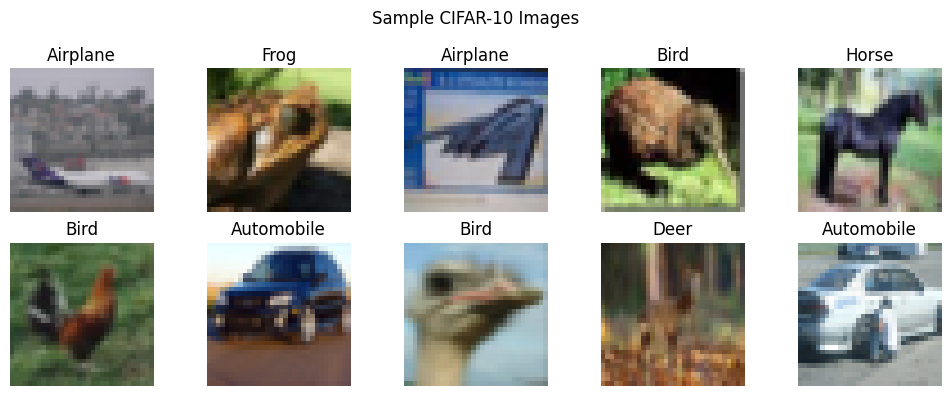

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

## Task 2: Transfer Learning

Pretrained model: **MobileNetV2** (ImageNet weights)

In [ ]:
IMG_SIZE = 96

def build_model(dense_units=128, trainable_base=False):
    inputs = Input(shape=(32, 32, 3))
    x = Resizing(IMG_SIZE, IMG_SIZE)(inputs)

    base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                              include_top=False,
                              weights='imagenet')
    base_model.trainable = trainable_base

    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(dense_units, activation='relu')(x)
    outputs = Dense(10, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model, base_model

model, base_model = build_model(dense_units=128, trainable_base=False)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Task 3: Model Training

Optimizer: Adam | Learning Rate: 0.001 | Batch Size: 32 | Epochs: 10 | Loss: Categorical Cross Entropy

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

start_time = time.time()

history = model.fit(x_train, y_train_cat,
                     validation_data=(x_test, y_test_cat),
                     batch_size=32,
                     epochs=10)

training_time = time.time() - start_time
print("Training Time (seconds):", training_time)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 23ms/step - accuracy: 0.7545 - loss: 0.7045 - val_accuracy: 0.7799 - val_loss: 0.6434
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8071 - loss: 0.5500 - val_accuracy: 0.8076 - val_loss: 0.5523
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8267 - loss: 0.4884 - val_accuracy: 0.7980 - val_loss: 0.5937
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8430 - loss: 0.4446 - val_accuracy: 0.8132 - val_loss: 0.5530
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8543 - loss: 0.4075 - val_accuracy: 0.8154 - val_loss: 0.5533
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8695 - loss: 0.3660 - val_accuracy: 0.8110 - val_loss: 0.5827
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8801 - loss: 0.3344 - val_accuracy: 0.8136 - val_loss: 0.5935
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8899 -

In [ ]:
train_acc_before = history.history['accuracy'][-1]
val_acc_before = history.history['val_accuracy'][-1]

print("Training Accuracy (before fine tuning):", train_acc_before)
print("Validation Accuracy (before fine tuning):", val_acc_before)

Training Accuracy (before fine tuning): 0.9117199778556824
Validation Accuracy (before fine tuning): 0.8039000034332275


## Task 4: Fine Tuning

Unfreeze the last convolution block of MobileNetV2 and train for additional epochs.

In [ ]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 20

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

start_time = time.time()

history_fine = model.fit(x_train, y_train_cat,
                          validation_data=(x_test, y_test_cat),
                          batch_size=32,
                          epochs=5)

fine_tune_time = time.time() - start_time
print("Fine Tuning Time (seconds):", fine_tune_time)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 21ms/step - accuracy: 0.7752 - loss: 0.8400 - val_accuracy: 0.7893 - val_loss: 0.6687
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.8665 - loss: 0.3826 - val_accuracy: 0.8093 - val_loss: 0.6829
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8993 - loss: 0.2817 - val_accuracy: 0.8065 - val_loss: 0.7489
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9221 - loss: 0.2230 - val_accuracy: 0.8303 - val_loss: 0.6213
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9378 - loss: 0.1743 - val_accuracy: 0.8319 - val_loss: 0.6584
Fine Tuning Time (seconds): 124.87656140327454


In [ ]:
train_acc_after = history_fine.history['accuracy'][-1]
val_acc_after = history_fine.history['val_accuracy'][-1]

print("Training Accuracy (after fine tuning):", train_acc_after)
print("Validation Accuracy (after fine tuning):", val_acc_after)

print("\nAccuracy Comparison")
print("Before fine tuning - Train:", train_acc_before, "Val:", val_acc_before)
print("After fine tuning  - Train:", train_acc_after, "Val:", val_acc_after)

Training Accuracy (after fine tuning): 0.9377999901771545
Validation Accuracy (after fine tuning): 0.8319000005722046

Accuracy Comparison
Before fine tuning - Train: 0.9117199778556824 Val: 0.8039000034332275
After fine tuning  - Train: 0.9377999901771545 Val: 0.8319000005722046


In [ ]:
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']
epochs_range = range(1, len(acc) + 1)

## Task 5: Model Evaluation

In [ ]:
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test.flatten()

test_accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
total_params = model.count_params()

print("Testing Accuracy:", test_accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Total Parameters:", total_params)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step
Testing Accuracy: 0.8319
Precision: 0.8354225730485126
Recall: 0.8319
F1-score: 0.8311943389544928
Total Parameters: 2423242


In [ ]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[813   3  26  13  15   0  14  11  78  27]
 [  7 881   1   8   2   0  11   1  29  60]
 [ 18   0 813  40  41  15  49  16   7   1]
 [  6   2  31 728  30  78  81  24   9  11]
 [  7   0  44  60 742  14  53  68  10   2]
 [  1   0  32 149  25 689  51  43   6   4]
 [  5   0  30  19   8   7 928   1   1   1]
 [ 10   3  15  27  37  13  12 870   6   7]
 [ 17   7   9   8   1   3   7   2 927  19]
 [  8  33   1   6   0   0   4   4  16 928]]


In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    Airplane       0.91      0.81      0.86      1000
  Automobile       0.95      0.88      0.91      1000
        Bird       0.81      0.81      0.81      1000
         Cat       0.69      0.73      0.71      1000
        Deer       0.82      0.74      0.78      1000
         Dog       0.84      0.69      0.76      1000
        Frog       0.77      0.93      0.84      1000
       Horse       0.84      0.87      0.85      1000
        Ship       0.85      0.93      0.89      1000
       Truck       0.88      0.93      0.90      1000

    accuracy                           0.83     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.84      0.83      0.83     10000



## Mandatory Plots

### Training and Validation Accuracy

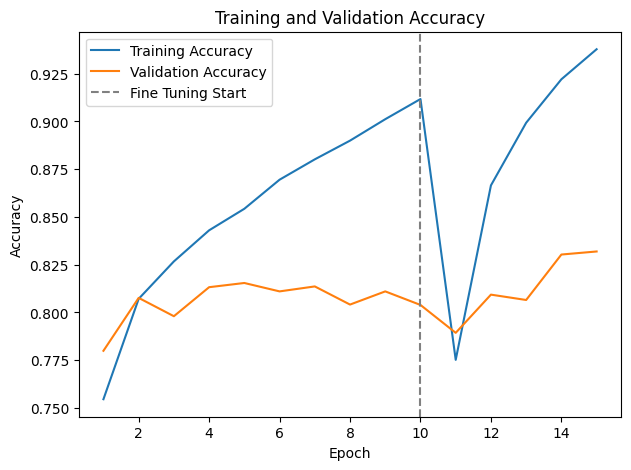

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axvline(x=len(history.history['accuracy']), color='gray', linestyle='--', label='Fine Tuning Start')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

### Training and Validation Loss

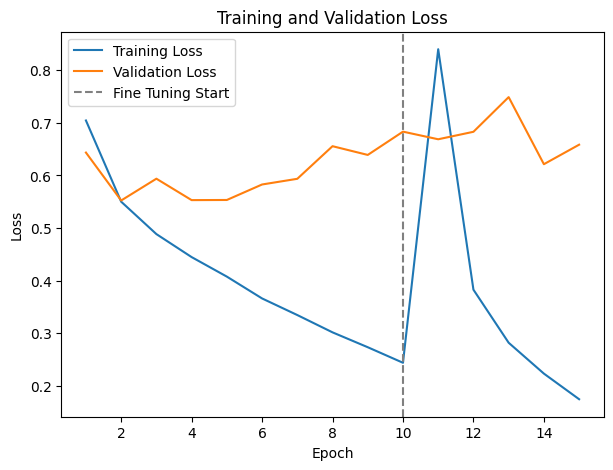

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axvline(x=len(history.history['loss']), color='gray', linestyle='--', label='Fine Tuning Start')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

### Confusion Matrix

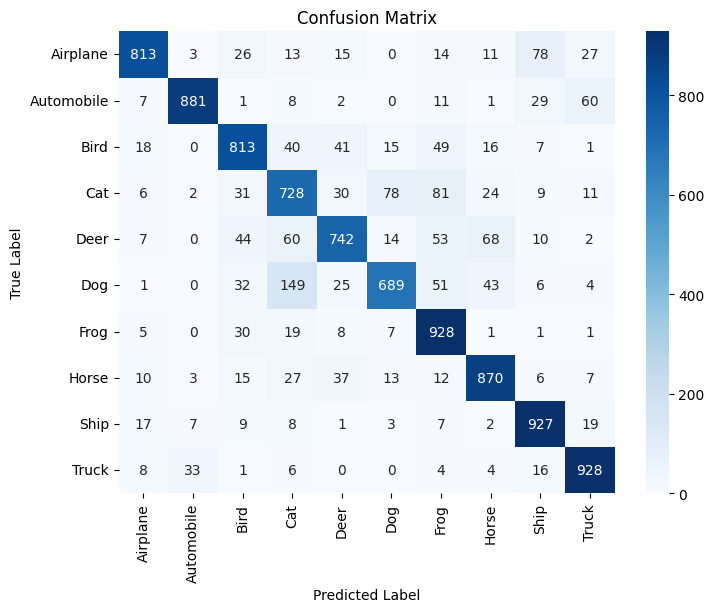

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Misclassified Images (Optional)

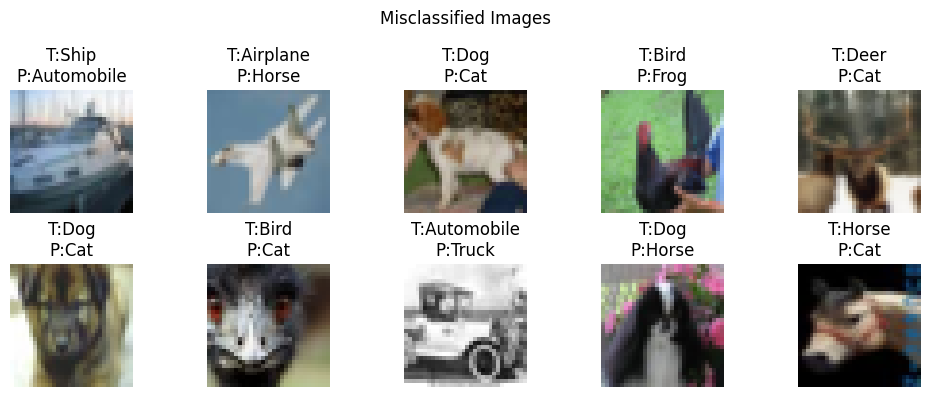

In [ ]:
misclassified_idx = np.where(y_pred != y_true)[0]

plt.figure(figsize=(10, 4))
for i, idx in enumerate(misclassified_idx[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}")
    plt.axis('off')
plt.suptitle("Misclassified Images")
plt.tight_layout()
plt.show()

## Hyperparameter Study

Compare performance using different settings: Learning Rate, Batch Size, Epochs, Optimizer, Dense Units, Frozen Layers.

In [ ]:
hyperparameter_configs = [
    {'lr': 0.001, 'batch_size': 32, 'epochs': 3, 'optimizer': 'adam', 'dense_units': 128, 'frozen': 'all'},
    {'lr': 0.0001, 'batch_size': 32, 'epochs': 3, 'optimizer': 'adam', 'dense_units': 256, 'frozen': 'all'},
    {'lr': 0.001, 'batch_size': 64, 'epochs': 3, 'optimizer': 'sgd', 'dense_units': 128, 'frozen': 'partial'},
]

hp_results = []

for cfg in hyperparameter_configs:
    trainable_base = (cfg['frozen'] == 'partial')
    hp_model, hp_base = build_model(dense_units=cfg['dense_units'], trainable_base=trainable_base)

    if trainable_base:
        ft_at = len(hp_base.layers) - 20
        for layer in hp_base.layers[:ft_at]:
            layer.trainable = False
        for layer in hp_base.layers[ft_at:]:
            layer.trainable = True

    if cfg['optimizer'] == 'adam':
        opt = Adam(learning_rate=cfg['lr'])
    else:
        opt = SGD(learning_rate=cfg['lr'])

    hp_model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    t0 = time.time()
    hp_history = hp_model.fit(x_train, y_train_cat,
                               validation_data=(x_test, y_test_cat),
                               batch_size=cfg['batch_size'],
                               epochs=cfg['epochs'],
                               verbose=0)
    elapsed = time.time() - t0

    hp_results.append({
        **cfg,
        'train_accuracy': hp_history.history['accuracy'][-1],
        'val_accuracy': hp_history.history['val_accuracy'][-1],
        'training_time': elapsed
    })

    print(cfg, "-> val_accuracy:", hp_history.history['val_accuracy'][-1])

{'lr': 0.001, 'batch_size': 32, 'epochs': 3, 'optimizer': 'adam', 'dense_units': 128, 'frozen': 'all'} -> val_accuracy: 0.8004000186920166
{'lr': 0.0001, 'batch_size': 32, 'epochs': 3, 'optimizer': 'adam', 'dense_units': 256, 'frozen': 'all'} -> val_accuracy: 0.8047000169754028
{'lr': 0.001, 'batch_size': 64, 'epochs': 3, 'optimizer': 'sgd', 'dense_units': 128, 'frozen': 'partial'} -> val_accuracy: 0.7846999764442444


In [ ]:
import pandas as pd
hp_df = pd.DataFrame(hp_results)
hp_df

,lr,batch_size,epochs,optimizer,dense_units,frozen,train_accuracy,val_accuracy,training_time
0,0.0010,32,3,adam,128,all,0.82794,0.8004,66.064163
1,0.0001,32,3,adam,256,all,0.81758,0.8047,66.264743
2,0.0010,64,3,sgd,128,partial,0.78974,0.7847,80.241180


## Results Summary

In [ ]:
results_summary = {
    'Training Accuracy': train_acc_after,
    'Testing Accuracy': test_accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1,
    'Training Time (s)': training_time + fine_tune_time,
    'Total Parameters': total_params
}

for k, v in results_summary.items():
    print(f"{k}: {v}")

Training Accuracy: 0.9377999901771545
Testing Accuracy: 0.8319
Precision: 0.8354225730485126
Recall: 0.8319
F1-score: 0.8311943389544928
Training Time (s): 325.91749453544617
Total Parameters: 2423242
